In [417]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
from itertools import groupby
from operator import itemgetter
import matplotlib.pyplot as plt
from arch import arch_model

In [418]:
aicsv = pd.read_csv("aiDataCSV.csv")
dccsv  = pd.read_csv("dotcomDataCSV.csv")

aicsv = aicsv.sort_values("Date").reset_index(drop = True)
dccsv = dccsv.sort_values("Date").reset_index(drop = True)

In [419]:
# Now we are going to create phases in the dotcom. JESUSSUSIFHKUJSGHFJKgadksgjk
# 0 = pre-bubble (94-97) 1 = Hype of Bubble (98-99) Burst = 2 (00-01)

dccsv["Date"] = pd.to_datetime(dccsv["Date"])
year = dccsv["Date"].dt.year

phaseConditions = [(year >= 1994) & (year <= 1997),
                   (year >= 1998) & (year <= 1999),
                   (year >= 2000) & (year <= 2001)]
phaseValues = [0, 1, 2]

dccsv["Phase"] = np.select(phaseConditions, phaseValues)

In [420]:
# allFeatures = ["CBPrice","SPPrice", "NYPrice", "NQPrice" , "CBOpen", "SPOpen", "NYOpen", "NQOpen",
# "CBHigh", "SPHigh", "NYHigh" , "NQHigh", "CBLow", "SPLow", "NYLow", "NQLow", "CBVol.",
# "SPVol.", "NYVol." , "NQVol.", "CBChange %", "SPChange %", "NYChange %", "NQChange %",
# "average first-day % return", " percentage priced above the midpoint of the original file price range",
# "VC IPOS"]

allFeatures = ["average first-day % return", " percentage priced above the midpoint of the original file price range",
"VC IPOS"]

In [421]:
for col in allFeatures:
    dccsv[col] = dccsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)

for col in allFeatures:
    aicsv[col] = aicsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)

/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_48564/2272989398.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dccsv[col] = dccsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)
/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_48564/2272989398.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aicsv[col] = aicsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str

In [422]:
print(dccsv)

         Date  CBPrice  CBOpen  CBHigh  CBLow  CBVol.  CBChange %   SPPrice  \
0  1994-02-01    14.87   10.81   16.31  10.21     NaN       39.89    467.10   
1  1994-03-01    20.45   12.58   21.94  11.58     NaN       37.53    445.80   
2  1994-04-01    13.77   23.61   28.30  13.05     NaN      -32.67    450.90   
3  1994-05-01    13.03   14.42   16.65  11.44     NaN       -5.37    456.50   
4  1994-06-01    14.97   13.16   17.71  10.48     NaN       14.89    444.30   
..        ...      ...     ...     ...    ...     ...         ...       ...   
90 2001-08-01    24.92   20.97   25.84  19.69     NaN       15.26  1,133.60   
91 2001-09-01    31.93   26.11   49.35  24.19     NaN       28.13  1,040.90   
92 2001-10-01    33.56   33.42   36.95  28.11     NaN        5.10  1,059.80   
93 2001-11-01    23.84   33.97   34.57  22.96     NaN      -28.96  1,139.50   
94 2001-12-01    23.80   25.92   26.38  21.12     NaN       -0.17  1,148.10   

      SPOpen    SPHigh  ...   NQPrice    NQOpen    

In [423]:
dccsv[allFeatures] = dccsv[allFeatures].fillna(0)
aicsv[allFeatures] = aicsv[allFeatures].fillna(0)

In [424]:
#Lets try to get monthly values from network characteristics plot. JESUS

AIBD = pd.read_csv("LeidenNetworkBURSTDATACharacteristicsAIGlobal.csv")
AID  = pd.read_csv("LeidenNetworkDENSITYCharacteristicsAIGlobal.csv")
AIP  = pd.read_csv("LeidenNetworkPATHCharacteristicsAIGlobal.csv")

GNBD  = pd.read_csv("LeidenNetworkBURSTDATACharacteristicsGN.csv")
GND  = pd.read_csv("LeidenNetworkDENSITYCharacteristicsGN.csv")
GNP  = pd.read_csv("LeidenNetworkPATHCharacteristicsGN.csv")

allAI = AIBD.merge(AIP, on = "Year").merge(AID, on = "Year")
allGN = GNBD.merge(GNP, on = "Year").merge(GND, on = "Year")

allAI.drop(["Unnamed: 0_x", 'Unnamed: 0_y',  'Unnamed: 0'], axis = 1, inplace = True)
allGN.drop(["Unnamed: 0_x", 'Unnamed: 0_y',  'Unnamed: 0'], axis = 1, inplace = True)

print(allGN.columns) #Index(['Year', 'Collabs', 'Path Length', 'Density'], dtype='object')

scaler = MinMaxScaler()
allAIscaled = scaler.fit_transform(allAI[['Collabs', 'Path Length', 'Density']])
allGNscaled = scaler.fit_transform(allGN[['Collabs', 'Path Length', 'Density']])

allAISdf = pd.DataFrame(allAIscaled, columns= ['Collabs', 'Path Length', 'Density'])
allAISdf["Year"] = allAI["Year"]

allGNSdf = pd.DataFrame(allGNscaled, columns= ['Collabs', 'Path Length', 'Density'])
allGNSdf["Year"] = allGN["Year"]


allGNSdf["Date"] = pd.to_datetime(allGNSdf["Year"].astype("str") + '-01-01')
allGNSdf.set_index("Date", inplace = True)
allGNSdf.drop(columns=["Year"], inplace = True)

monthly = allGNSdf.resample("MS").mean()
monthly = monthly.interpolate(method = "linear")

monthly.reset_index(inplace = True)

print(monthly.head(10))

# allAISdf["Date"] = pd.to_datetime(allAISdf["Year"].astype("str") + '-01-01')
# allAISdf.set_index("Date", inplace = True)
# allAISdf.drop(columns=["Year"], inplace = True)

# monthly = allAISdf.resample("MS").mean()
# monthly = monthly.interpolate(method = "linear")

# monthly.reset_index(inplace = True)

# print(monthly.head(10))

Index(['Year', 'Collabs', 'Path Length', 'Density'], dtype='object')
        Date   Collabs  Path Length   Density
0 2017-01-01  0.000294     0.222511  0.147236
1 2017-02-01  0.004100     0.271143  0.137944
2 2017-03-01  0.007907     0.319775  0.128651
3 2017-04-01  0.011714     0.368407  0.119359
4 2017-05-01  0.015521     0.417039  0.110066
5 2017-06-01  0.019328     0.465671  0.100774
6 2017-07-01  0.023134     0.514303  0.091481
7 2017-08-01  0.026941     0.562935  0.082189
8 2017-09-01  0.030748     0.611566  0.072896
9 2017-10-01  0.034555     0.660198  0.063604


In [425]:
dccsv2 = (dccsv[allFeatures])

dccsv2["Date"] = dccsv["Date"].copy()

dccsv2["Return"] = np.log(dccsv2["CBPrice"] / dccsv2["CBPrice"].shift(1))
dccsv2 = dccsv2[["Date", "Return"]].dropna()

merged = pd.merge(dccsv2,monthly, on="Date", how = "inner" )
merged["Collabs12"] = merged["Collabs"].shift(12)
merged["Path Length12"] = merged["Path Length"].shift(12)
merged["Density12"] = merged["Density"].shift(12)

merged.dropna(subset=['Collabs12', 'Path Length12', 'Density12'], inplace=True)


print(merged)

# aicsv2 = (aicsv[allFeatures])

# aicsv2["Date"] = aicsv["Date"].copy()

# print(aicsv2)

# aicsv2["Return"] = np.log(aicsv2["CBPrice"] / aicsv2["CBPrice"].shift(1))
# aicsv2 = aicsv2[["Date", "Return"]].dropna()
# aicsv2["Date"] = pd.to_datetime(aicsv2["Date"])
# monthly["Date"] = pd.to_datetime(monthly["Date"])
# merged = pd.merge(aicsv2,monthly, on="Date", how = "inner" )
# merged["Collabs12"] = merged["Collabs"].shift(12)
# merged["Path Length12"] = merged["Path Length"].shift(12)
# merged["Density12"] = merged["Density"].shift(12)

# merged.dropna(subset=['Collabs12', 'Path Length12', 'Density12'], inplace=True)


# print(merged)

     CBPrice  CBOpen  CBHigh  CBLow  CBVol.  CBChange %        Date
0      13.34   20.89   22.81  12.86     0.0      -36.39  2015-02-01
1      15.29   13.90   17.19  12.54     0.0       14.62  2015-03-01
2      14.55   15.32   16.66  12.12     0.0       -4.84  2015-04-01
3      13.84   13.98   16.36  11.82     0.0       -4.88  2015-05-01
4      18.23   13.92   19.80  11.93     0.0       31.72  2015-06-01
..       ...     ...     ...    ...     ...         ...         ...
117    13.51   22.96   23.09  13.49     0.0      -41.67  2024-11-01
118    17.35   14.08   28.32  12.70     0.0       28.42  2024-12-01
119    16.43   17.21   22.51  14.58     0.0       -5.30  2025-01-01
120    19.63   20.36   22.40  14.74     0.0       19.48  2025-02-01
121    22.28   19.83   29.57  16.97     0.0       13.50  2025-03-01

[122 rows x 7 columns]
         Date    Return   Collabs  Path Length   Density  Collabs12  \
12 2018-01-01  0.204123  0.045975     0.806094  0.035726   0.000294   
13 2018-02-01  0.3

/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_48564/3968045511.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aicsv2["Date"] = aicsv["Date"].copy()
/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_48564/3968045511.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aicsv2["Return"] = np.log(aicsv2["CBPrice"] / aicsv2["CBPrice"].shift(1))


                          AR-X - GARCH Model Results                          
Dep. Variable:                 Return   R-squared:                       0.082
Mean Model:                      AR-X   Adj. R-squared:                  0.035
Vol Model:                      GARCH   Log-Likelihood:              -0.439324
Distribution:                  Normal   AIC:                           16.8786
Method:            Maximum Likelihood   BIC:                           36.3252
                                        No. Observations:                   84
Date:                Thu, Jun 05 2025   Df Residuals:                       79
Time:                        07:09:52   Df Model:                            5
                                 Mean Model                                
                    coef    std err          t      P>|t|  95.0% Conf. Int.
---------------------------------------------------------------------------
Const             0.1975      0.598      0.330      0.741 [ -

/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/GARCH/.conda/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.06191. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


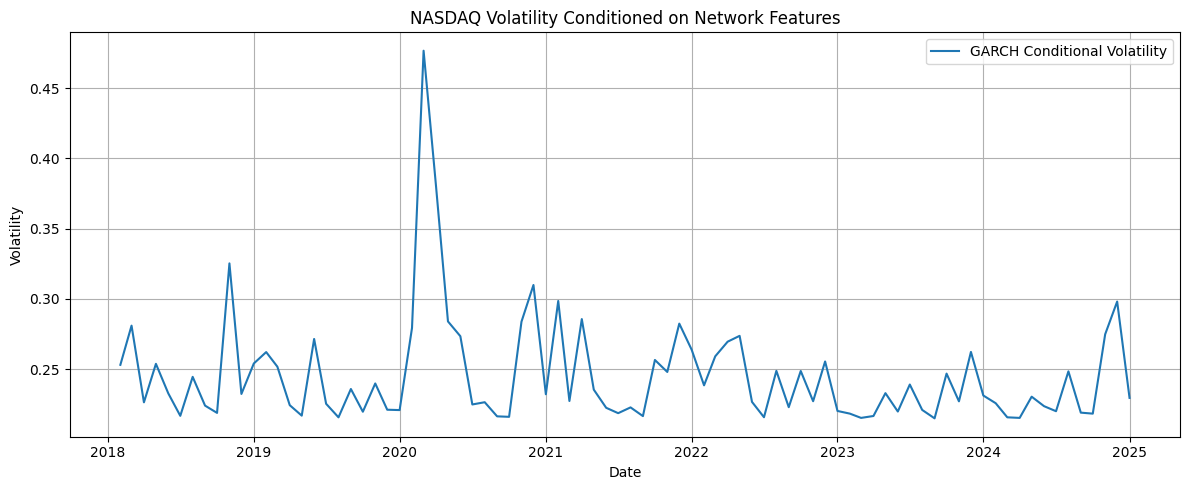

In [426]:
# X = merged[["Collabs12", "Path Length12", "Density12"]]
# returns = merged["Return"]

# model = arch_model(returns, x = X, mean = "ARX", lags = 1, vol = "GARCH", p = 1, q = 1)
# res = model.fit(disp= "off")

# print(res.summary())

# merged['Volatility'] = res.conditional_volatility
# plt.figure(figsize=(12, 5))
# plt.plot(merged['Date'], merged['Volatility'], label='GARCH Conditional Volatility')
# plt.title("NASDAQ Volatility Conditioned on Network Features")
# plt.xlabel("Date")
# plt.ylabel("Volatility")
# plt.legend()
# plt.tight_layout()
# plt.grid(True)
# plt.show()


X = merged[["Collabs12", "Path Length12", "Density12"]]
returns = merged["Return"]

model = arch_model(returns, x = X, mean = "ARX", lags = 1, vol = "GARCH", p = 1, q = 1)
res = model.fit(disp= "off")

print(res.summary())

merged['Volatility'] = res.conditional_volatility
plt.figure(figsize=(12, 5))
plt.plot(merged['Date'], merged['Volatility'], label='GARCH Conditional Volatility')
plt.title("NASDAQ Volatility Conditioned on Network Features")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()